In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from diptest import diptest
from binning import *

In [2]:
"""
We assume that the spot coordinates (avaiable with the datasets) are in um unit.
"""

'\nWe assume that the spot coordinates (avaiable with the datasets) are in um unit.\n'

### Merfish Lung Cancer

In [15]:
binned_path = path + "ST_55_python.h5ad"

In [3]:

path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_Lung_Cancer/ST/"

unbinned_st_path = path + "unbinned_ST/ST_embeddings.h5ad"

binned_path = path + "ST_55_python.h5ad"

dataset =  "merfish_lung_cancer"
celltype_col = "celltype"
spot_diameter = 55 #55 # 550 -> 510 # 100->6, 9, etc.
coord1 = 0
coord2 = 1

combined_adata = binning(unbinned_st_path, spot_diameter, celltype_col, dataset, coord1, coord2)
print (combined_adata)

Number of spots in mask: 8
Number of spots in mask: 23
Number of spots in mask: 33
Number of spots in mask: 24
Number of spots in mask: 20
Number of spots in mask: 23
Number of spots in mask: 2
Number of spots in mask: 6
Number of spots in mask: 20
Number of spots in mask: 27
Number of spots in mask: 24
Number of spots in mask: 35
Number of spots in mask: 27
Number of spots in mask: 26
Number of spots in mask: 21
Number of spots in mask: 24
Number of spots in mask: 19
Number of spots in mask: 18
Number of spots in mask: 9
Number of spots in mask: 8
Number of spots in mask: 29
Number of spots in mask: 35
Number of spots in mask: 28
Number of spots in mask: 23
Number of spots in mask: 35
Number of spots in mask: 36
Number of spots in mask: 34
Number of spots in mask: 8
Number of spots in mask: 16
Number of spots in mask: 18
Number of spots in mask: 27
Number of spots in mask: 30
Number of spots in mask: 35
Number of spots in mask: 31
Number of spots in mask: 34
Number of spots in mask: 2

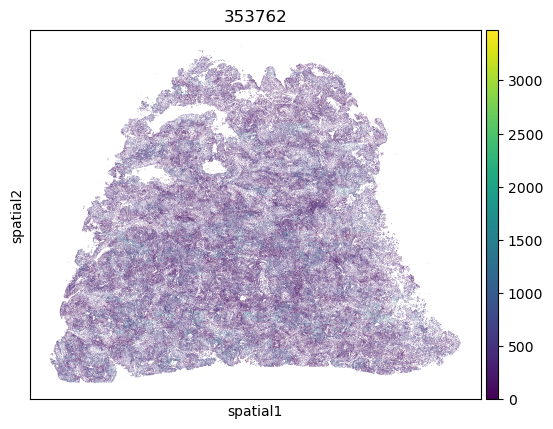

In [4]:
st_adata = sc.read_h5ad(unbinned_st_path)
st_adata.obs["umi_count"] = st_adata.X.sum(axis = 1)
sc.pl.embedding(st_adata, basis = "spatial", color = "umi_count", title = st_adata.shape)

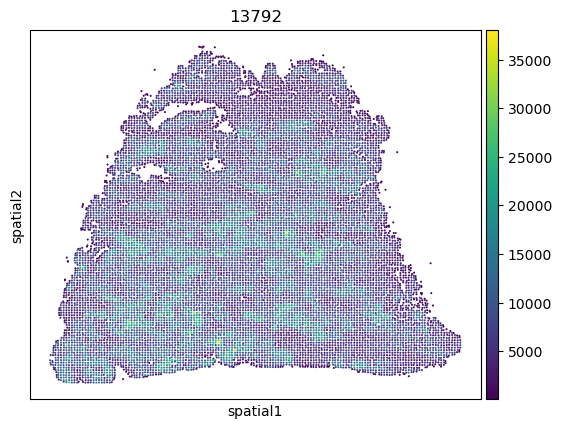

In [5]:
combined_adata.obs["umi_count"] = combined_adata.X.sum(axis = 1)
sc.pl.embedding(combined_adata, basis = "spatial", color = "umi_count", title = combined_adata.shape)

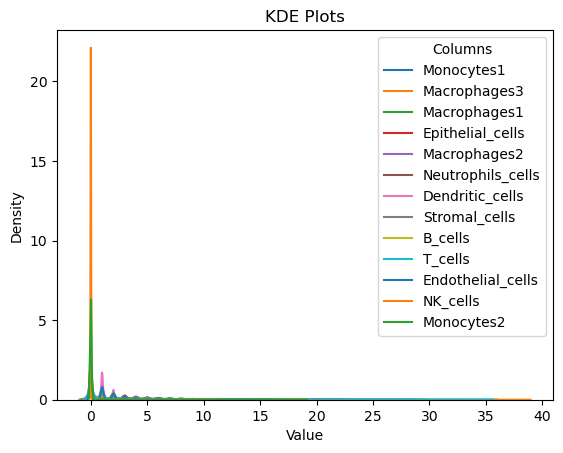

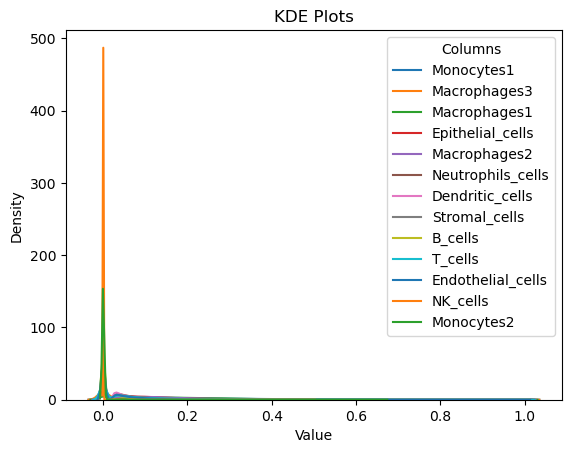

In [6]:
dt = combined_adata.obs
dt = dt[dt.columns[:-2]]
dt_ = dt.div(dt.sum(axis=1),axis=0)
diptest(dt)
diptest(dt_)

In [7]:
dt = dt.sort_index(axis=1)

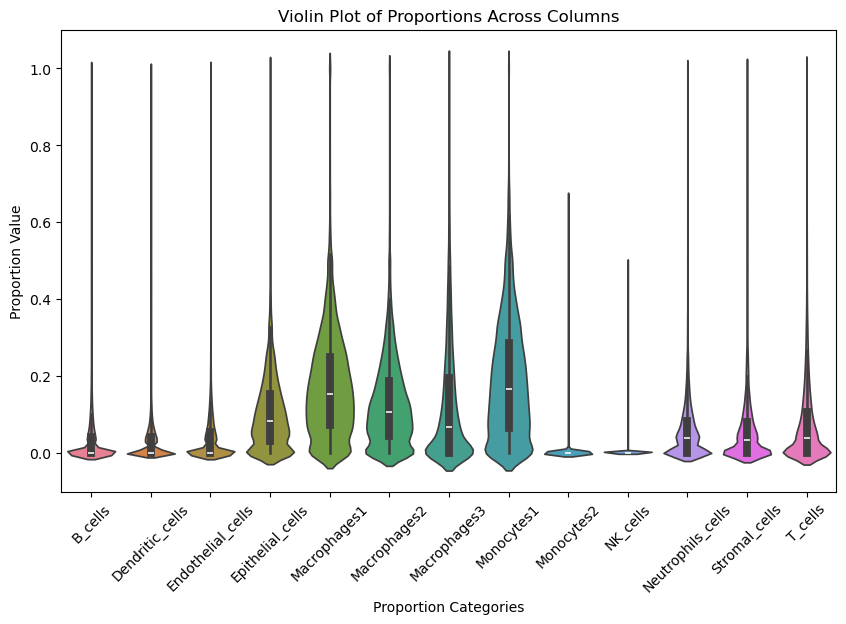

In [8]:
dt_ = dt_.sort_index(axis=1)

# Violin plot for more detailed distribution visualization
plt.figure(figsize=(10, 6))
sns.violinplot(data=dt_)
plt.title('Violin Plot of Proportions Across Columns')
plt.ylabel('Proportion Value')
plt.xlabel('Proportion Categories')
plt.xticks(rotation=45) #after creating the plot. Here's how you can adjust the code:
plt.show()

In [9]:
dt_

,B_cells,Dendritic_cells,Endothelial_cells,Epithelial_cells,Macrophages1,Macrophages2,Macrophages3,Monocytes1,Monocytes2,NK_cells,Neutrophils_cells,Stromal_cells,T_cells
0,0.000000,0.000000,0.250000,0.000000,0.250000,0.250000,0.000000,0.125000,0.0,0.00,0.000000,0.000000,0.125000
0,0.043478,0.000000,0.000000,0.130435,0.217391,0.304348,0.130435,0.043478,0.0,0.00,0.000000,0.086957,0.043478
0,0.030303,0.030303,0.030303,0.030303,0.060606,0.575758,0.030303,0.090909,0.0,0.00,0.060606,0.060606,0.000000
0,0.041667,0.000000,0.000000,0.125000,0.125000,0.375000,0.125000,0.041667,0.0,0.00,0.000000,0.000000,0.166667
0,0.000000,0.000000,0.000000,0.050000,0.250000,0.050000,0.100000,0.300000,0.0,0.05,0.200000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0.000000,0.000000,0.125000,0.250000,0.000000,0.125000,0.000000,0.000000,0.0,0.00,0.250000,0.000000,0.250000
0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00,0.000000,0.000000,0.000000
0,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00,0.000000,0.000000,0.666667
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00,0.000000,0.000000,1.000000


(array([2.370e+02, 8.800e+01, 8.400e+01, 6.700e+01, 9.100e+01, 9.700e+01,
        2.310e+02, 1.290e+02, 1.670e+02, 1.910e+02, 2.150e+02, 2.360e+02,
        6.550e+02, 3.650e+02, 4.600e+02, 4.430e+02, 4.880e+02, 4.940e+02,
        5.260e+02, 1.063e+03, 5.380e+02, 5.320e+02, 5.210e+02, 4.790e+02,
        5.170e+02, 9.190e+02, 3.790e+02, 4.320e+02, 4.040e+02, 3.740e+02,
        3.310e+02, 5.600e+02, 2.300e+02, 2.320e+02, 1.850e+02, 1.410e+02,
        1.180e+02, 1.070e+02, 1.920e+02, 5.300e+01, 4.600e+01, 3.700e+01,
        3.200e+01, 2.400e+01, 3.100e+01, 1.100e+01, 6.000e+00, 6.000e+00,
        3.000e+00, 4.000e+00, 1.000e+01, 3.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 5.000e+00]),
 array([ 1.        ,  2.15789474,  3.31578947,  4.47368421,  5.63157895,
         6.78947368,  7.94736842,  9.10526316, 10.26315789, 11.42105263,
        12.57894737, 13.73684211, 14.89473684, 16.05263158, 17.21052632,
        18.36842105, 19.52631579, 20.68421053, 21.84210526, 23.        ,

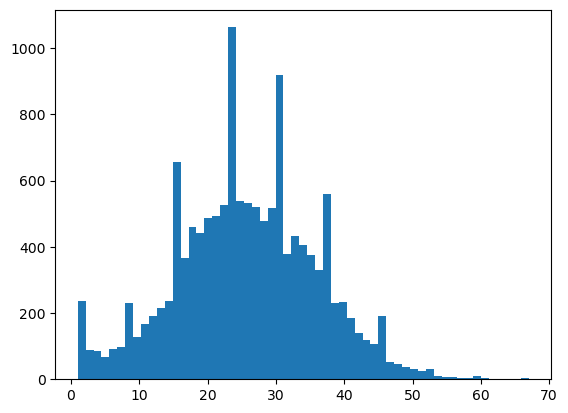

In [10]:
a = dt.sum(axis = 1)
plt.hist(a, bins='auto')

In [11]:
combined_adata.write_h5ad(binned_path)
no_of_cells = dt.sum(axis = 1)
no_of_cells.to_csv(path + "no_of_cells.csv")

res_path = "/data/Ajita/Spatial/Datasets/Spatial_Deconvolution/_Image_Binned_datasets/MERFISH_Lung_Cancer/final_outputs_repo/gt.h5ad"

columns = combined_adata.obs.columns.tolist()[:-2]
loc = combined_adata.obsm["spatial"]#.to_numpy()
columns.sort()

ann_test = anndata.AnnData(dt_.to_numpy())
ann_test.obsm["Average_STAGATE_ReX"] = dt_.to_numpy()
ann_test.var_names = columns
ann_test.obsm["spatial"] = loc

print (ann_test)    
ann_test.write_h5ad(res_path)  

AnnData object with n_obs × n_vars = 13792 × 13
    obsm: 'Average_STAGATE_ReX', 'spatial'


In [16]:
combined_adata.var_names = st_adata.var_names
combined_adata.obs_names = [str(i) for i in range(len(combined_adata))]
print (combined_adata.obs_names, combined_adata.var_names)
combined_adata.write_h5ad(binned_path)

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '13782', '13783', '13784', '13785', '13786', '13787', '13788', '13789',
       '13790', '13791'],
      dtype='object', length=13792) Index(['ACKR3', 'ACTA2', 'ADAMTS4', 'AKT1', 'AKT2', 'AKT3', 'AMOTL2', 'ANGPT1',
       'ANGPT2', 'APC',
       ...
       'WNT3A', 'WNT5A', 'WWTR1', 'XBP1', 'XCL1', 'XCR1', 'YAP1', 'ZAP70',
       'ZBED2', 'ZEB1'],
      dtype='object', length=488)


In [13]:
combined_adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '13782', '13783', '13784', '13785', '13786', '13787', '13788', '13789',
       '13790', '13791'],
      dtype='object', length=13792)